# Análise exploratória - Geral

* Bibliotecas utilizadas na criação dos gráficos:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors 
import numpy as np
import seaborn as sns
import squarify # para o treemap
import math
from matplotlib.patches import Rectangle


def plot_colortable(colors, *, ncols=4, sort_colors=True):

    cell_width = 212
    cell_height = 22
    swatch_width = 48
    margin = 12

    if sort_colors is True:
        names = sorted(
            colors, key=lambda c: tuple(mcolors.rgb_to_hsv(mcolors.to_rgb(c))))
    else:
        names = list(colors)

    n = len(names)
    nrows = math.ceil(n / ncols)

    width = cell_width * ncols + 2 * margin
    height = cell_height * nrows + 2 * margin
    dpi = 72

    fig, ax = plt.subplots(figsize=(width / dpi, height / dpi), dpi=dpi)
    fig.subplots_adjust(margin/width, margin/height,
                        (width-margin)/width, (height-margin)/height)
    ax.set_xlim(0, cell_width * ncols)
    ax.set_ylim(cell_height * (nrows-0.5), -cell_height/2.)
    ax.yaxis.set_visible(False)
    ax.xaxis.set_visible(False)
    ax.set_axis_off()

    for i, name in enumerate(names):
        row = i % nrows
        col = i // nrows
        y = row * cell_height

        swatch_start_x = cell_width * col
        text_pos_x = cell_width * col + swatch_width + 7

        ax.text(text_pos_x, y, name, fontsize=14,
                horizontalalignment='left',
                verticalalignment='center')

        ax.add_patch(
            Rectangle(xy=(swatch_start_x, y-9), width=swatch_width,
                      height=18, facecolor=colors[name], edgecolor='0.7')
        )

    return fig

* Base de dados modificada:

In [2]:
df_SRAG = pd.read_parquet('../Dados/df_SRAG2025.parquet')

* Devido ao tamanho da base de dados ser consideravelmente grande, com muitas variáveis e observações, separaremos por tópicos os gráficos criados, sendo eles: _Sexo, Localidade, Faixa Etária e Internações_.

## Sexo

* Inicialmente, com um gráfico de barras e um de pizza, apresentaremos a quantidade e proporção de registros dos pacientes divididos pelos sexos.

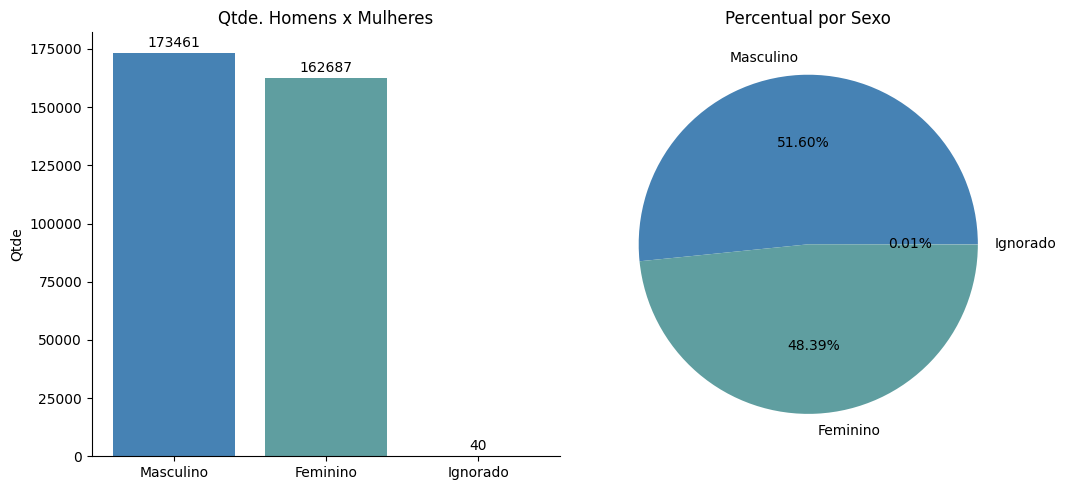

In [3]:
df_SRAG['SEXO'] = df_SRAG['CS_SEXO'].map({
    'M': 'Masculino',
    'F': 'Feminino',
    'I': 'Ignorado'
}).copy()

fig, axs = plt.subplots(1, 2, figsize= (11,5))
colors = ['steelblue', 'cadetblue', 'lightsteelblue', 'lightblue']
#colors = ['steelblue', 'cadetblue']

# configurações para o gráfico de barras 

bars = axs[0].bar(df_SRAG.SEXO.value_counts().index, df_SRAG.SEXO.value_counts().values, color=colors)
axs[0].bar_label(bars, padding=2, color = 'black', fontsize = 10)
axs[0].set(title='Qtde. Homens x Mulheres', ylabel = 'Qtde')
axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)

# configurações para o gráfico de pizza 

slicesPercent = df_SRAG['SEXO'].value_counts(normalize = True) * 100
slices = (slicesPercent).array
sex = df_SRAG.SEXO.value_counts().index
axs[1].pie(slices, labels=sex, autopct='%1.2f%%', colors=colors)
axs[1].set(title='Percentual por Sexo')

plt.tight_layout()
plt.show()

* A diferença entre homens e mulheres é irrisória, ou seja, pelos registros da base de dados os pacientes que foram buscar atendimento para SRAG foi bem equilibrado entre os sexos.

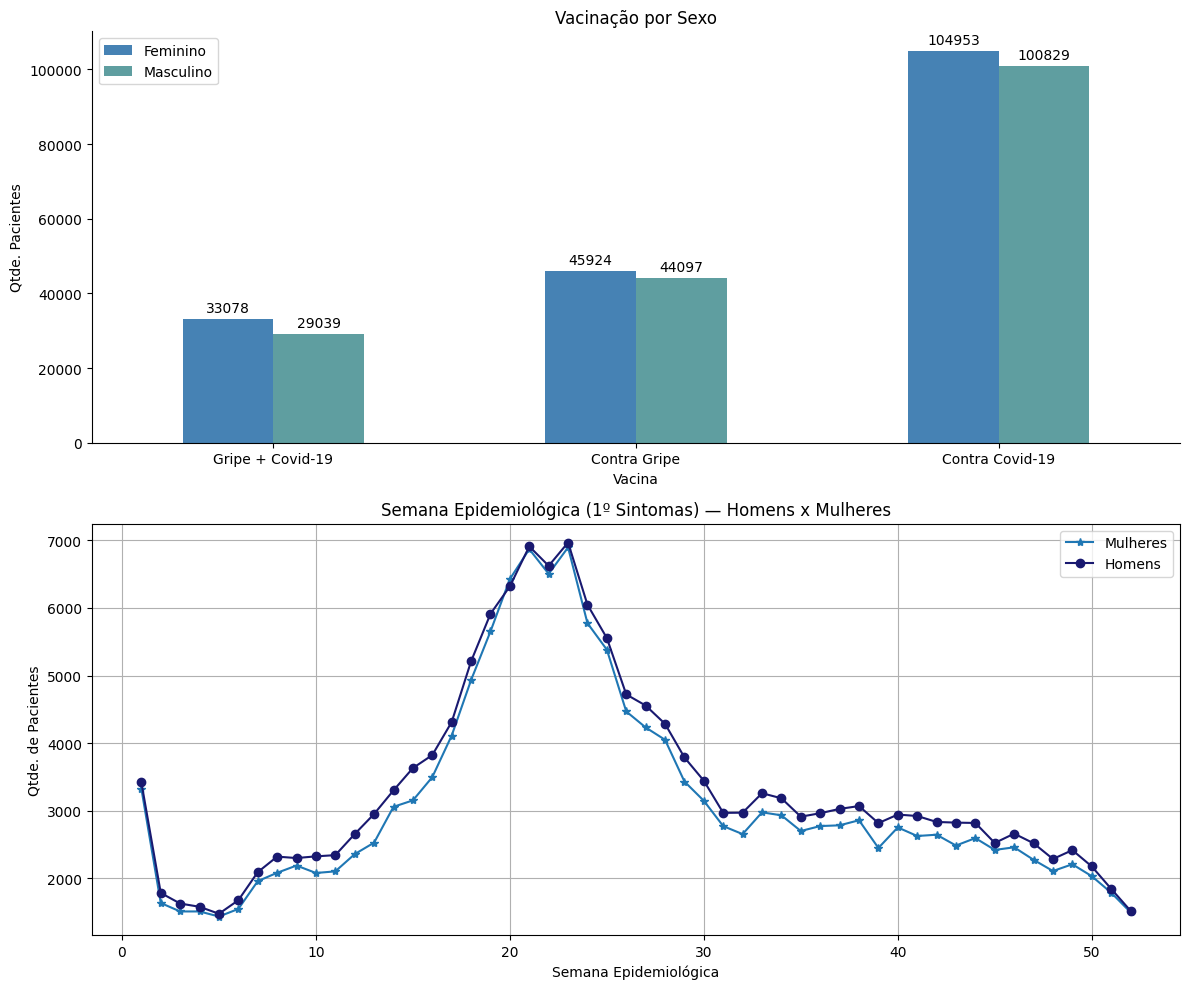

In [ ]:
# Remover valores ignorados
df_SRAG = df_SRAG[df_SRAG['SEXO'] != 'Ignorado']

# Criar coluna indicando quem tomou as DUAS vacinas
df_SRAG['AMBAS_VACINAS'] = (
    (df_SRAG['VACINA'].fillna(0) == 1) &
    (df_SRAG['VACINA_COV'].fillna(0) == 1)
).astype(int)

# Transformar em formato longo
df_long = df_SRAG.melt(
    id_vars='SEXO',
    value_vars=['VACINA_COV', 'VACINA', 'AMBAS_VACINAS'],
    var_name='Vacina',
    value_name='Tomou'
)

# Filtrar apenas quem tomou
df_filtrado = df_long[df_long['Tomou'] == 1]

# Contagem
contagem = (
    df_filtrado
    .groupby(['Vacina', 'SEXO'])
    .size()
    .unstack(fill_value=0)
)

# Renomear categorias
contagem.rename(index={
    'VACINA': 'Contra Gripe',
    'VACINA_COV': 'Contra Covid-19',
    'AMBAS_VACINAS': 'Gripe + Covid-19'
}, inplace=True)


fig, axs = plt.subplots(2, 1, figsize=(12,10))

# Gráfico de barras agrupadas

contagem.plot(
    kind='bar',
    stacked=False,
    color=colors,
    ax=axs[0]
)

axs[0].set(
    title='Vacinação por Sexo',
    ylabel='Qtde. Pacientes'
)

axs[0].legend(loc='upper left')
axs[0].tick_params(rotation=0)

axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)

# Valores acima das barras
for container in axs[0].containers:
    axs[0].bar_label(container, padding=3)


# Gráfico de linhas

registros_sexo = (
    df_SRAG
    .groupby(['SEM_PRI', 'SEXO'])
    .size()
    .reset_index(name='qtde_registros_sexo')
)

pivot = registros_sexo.pivot(
    index='SEM_PRI',
    columns='SEXO',
    values='qtde_registros_sexo'
)

axs[1].plot(
    pivot.index,
    pivot['Feminino'],
    label='Mulheres',
    marker='*'
)

axs[1].plot(
    pivot.index,
    pivot['Masculino'],
    label='Homens',
    color='midnightblue',
    marker='o'
)

axs[1].set(
    title='Semana Epidemiológica (1º Sintomas) — Homens x Mulheres',
    xlabel='Semana Epidemiológica',
    ylabel='Qtde. de Pacientes'
)

axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

* **BARRAS AGRUPADAS:**
    * A vacinação contra gripe diz respeito a última campanha nacional;
    * Evidentemente a vacinação contra Covid-19 apresenta números mais expressivos por conta da pandemia e a campanha massiva de vacinação nos anos anteriores.

* **LINHAS:**
    * A partir da 10ª semana epidemiológica o registro pacientes apresenta uma crescente significativa, onde alcança o seu pico entre a 20ª e 25ª semana, o que coincide com a época de outono e início do inverno. onde o tempo seco na maior parte do país propicia a proliferação do vírus.

## Faixa Etária

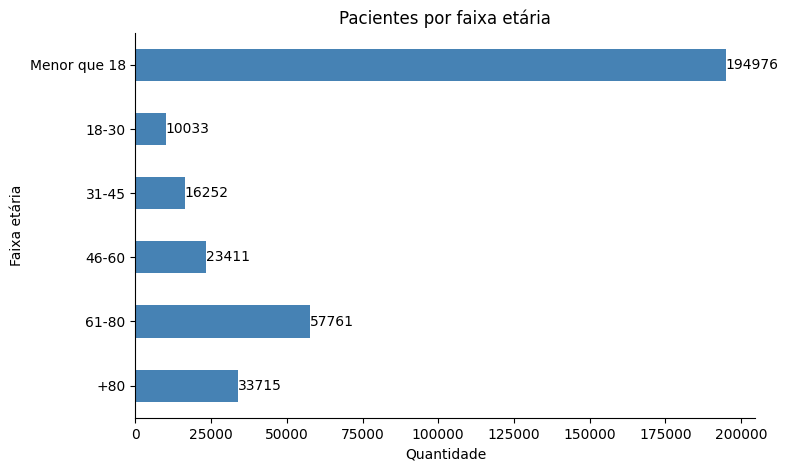

FAIXA_ETARIA
Menor que 18    194976
18-30            10033
31-45            16252
46-60            23411
61-80            57761
+80              33715
Name: count, dtype: int64


In [28]:
# Corrigir idade
df_SRAG['IDADE_ANOS'] = df_SRAG['NU_IDADE_N'].copy()

# Se a idade estiver em dias ou meses será transformada em 0 anos
df_SRAG.loc[df_SRAG['TP_IDADE'].isin([1, 2]), 'IDADE_ANOS'] = 0

# criação dos intervalos
bins = [0, 17, 30, 45, 60, 80, 150]

labels = [
    'Menor que 18',
    '18-30',
    '31-45',
    '46-60',
    '61-80',
    '+80'
]

df_SRAG['FAIXA_ETARIA'] = pd.cut(
    df_SRAG['IDADE_ANOS'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

count = (
    df_SRAG['FAIXA_ETARIA']
    .value_counts()
    .sort_index(ascending=False)
)

# criação do gráfico
ax = count.plot(kind='barh', 
                color='steelblue', 
                figsize=(8,5))

ax.set(title ='Pacientes por faixa etária', 
       xlabel = 'Quantidade', 
       ylabel = 'Faixa etária')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for container in ax.containers:
    ax.bar_label(container)

plt.show()

print(
    df_SRAG['FAIXA_ETARIA']
    .value_counts()
    .sort_index()
)

* A quantidade de pacientes com menos de 18 anos é consideravelmente maior que as das outras faixas de idade. Esse valor provavelmente é maior por conta dos bebês/crianças, esse grupo de pacientes pode ser considerado mais "sensível" para esse tipo de doença, então os pais são mais propensos a procurar ajuda especializada para seus filhos, diferente de um adulto, que posterga o atendimento ao máximo possível. Por isso, apenas para confirmar essa hipótese vamos filtrar ainda mais, retornando apenas os pacientes menores de idade.

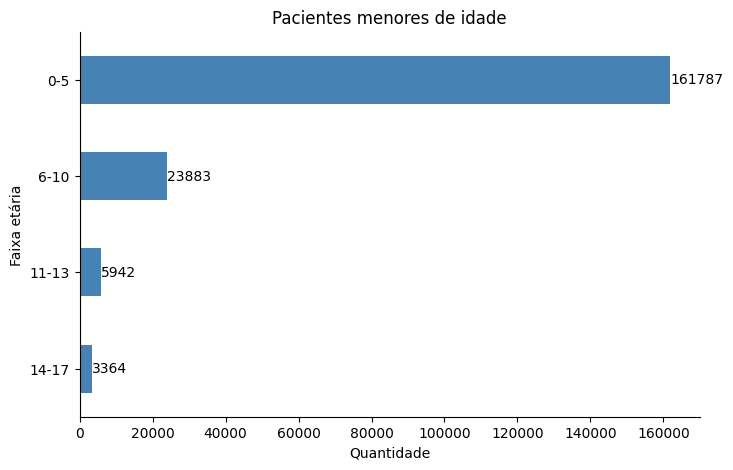

In [8]:
# Filtrar apenas menores de idade
df_menores = df_SRAG[df_SRAG['IDADE_ANOS'] < 18].copy()

# Criação das faixas etárias
bins = [0, 5, 10, 13, 17]

labels = [
    '0-5',
    '6-10',
    '11-13',
    '14-17'
]

df_menores['FAIXA_ETARIA'] = pd.cut(
    df_menores['IDADE_ANOS'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Contagem
count = (
    df_menores['FAIXA_ETARIA']
    .value_counts()
    .sort_index(ascending = False)
)

# Gráfico
ax = count.plot(
    kind='barh',
    color='steelblue',
    figsize=(8,5)
)

ax.set(title ='Pacientes menores de idade', 
       xlabel = 'Quantidade', 
       ylabel = 'Faixa etária')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Valores acima das barras
for container in ax.containers:
    ax.bar_label(container)

plt.show()

## Localidade

* Iniciar com informações gerais sobre as localidades.

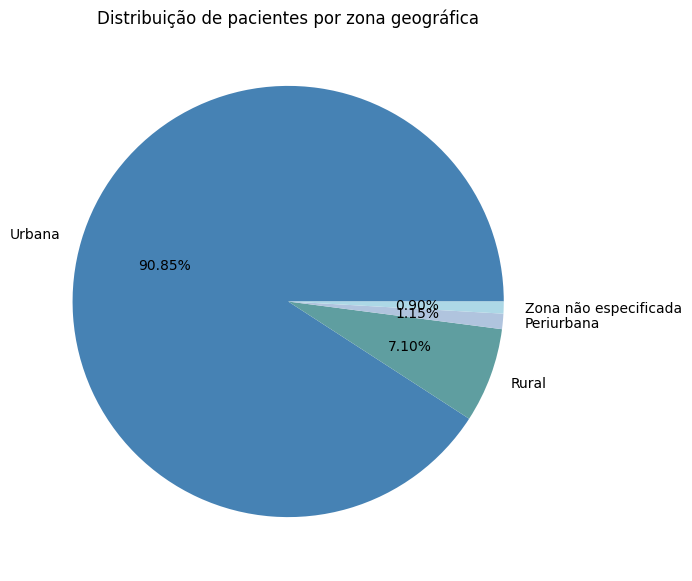

In [9]:
zona_dict = {
    '1': 'Urbana',
    '2': 'Rural', 
    '3': 'Periurbana', 
    '9': 'Zona não especificada'
}

df_SRAG['ZONA_LABEL'] = df_SRAG['CS_ZONA'].astype('string').copy()
df_SRAG['ZONA_PACIENTE'] = df_SRAG['ZONA_LABEL'].replace(zona_dict).copy()

slicesPercent = df_SRAG['ZONA_PACIENTE'].value_counts(normalize = True) * 100
slices = (slicesPercent).array

plt.figure(figsize=(7,7))
zone = df_SRAG.ZONA_PACIENTE.value_counts().index
plt.pie(slices, labels=zone, autopct='%1.2f%%', colors=colors)
plt.title('Distribuição de pacientes por zona geográfica', loc='center')

plt.show()


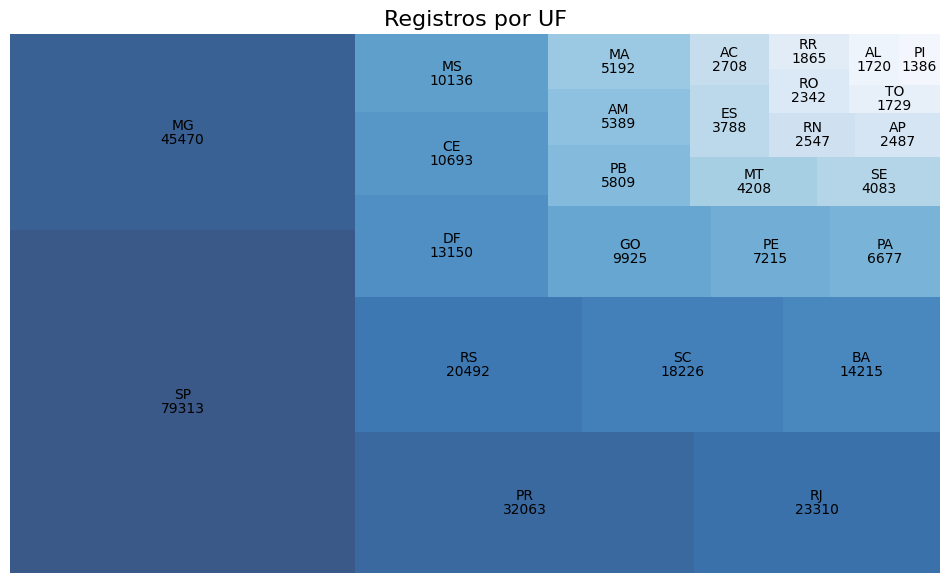

In [22]:
dados = df_SRAG['SG_UF_NOT'].value_counts()

# Gerar uma paleta em tons de azul proporcional ao número de UFs
cores = plt.cm.Blues_r(
    [i/len(dados) for i in range(len(dados))]
)

plt.figure(figsize=(12, 7))
squarify.plot(
    sizes=dados.values,     # valores (área de cada quadrado)
    label=dados.index,      # rótulos (as UFs)
    value=dados.values,     # mostra os valores nos quadrados
    color=cores,
    alpha=0.8               # transparência
)

plt.title("Registros por UF", fontsize=16)
plt.axis("off")  # tira os eixos
plt.show()

* As tabelas a seguir trazem as 20 regiões e os 20 municípios que mais registraram casos de Síndrome Respiratória Aguda Grave no Brasil.

In [10]:
#Municípios e regiões que tiveram mais registros de SRAG

from IPython.display import display_html

df_SRAG['MUNICIPIO'] = df_SRAG['ID_MUNICIP'].copy()
df_SRAG['REGIAO'] = df_SRAG['ID_REGIONA'].copy()
municipio = df_SRAG.groupby("MUNICIPIO").size().reset_index(name="QUANTIDADE_PACIENTES")
regiao = df_SRAG.groupby("REGIAO").size().reset_index(name="QUANTIDADE_PACIENTES")

municipio_top_mais = municipio.sort_values(by="QUANTIDADE_PACIENTES", ascending=False).head(20).style.background_gradient(cmap="Blues").set_table_attributes('style="display:inline-block; width:45%; margin-top:36px;"')
regiao_top_mais = regiao.sort_values(by="QUANTIDADE_PACIENTES", ascending=False).head(20).style.background_gradient(cmap="Blues").set_table_attributes('style="display:inline-block; width:45%; margin-top:36px;"')

municipio_top_menos = municipio.sort_values(by="QUANTIDADE_PACIENTES", ascending=False).tail(20).style.background_gradient(cmap="Blues").set_table_attributes('style="display:inline-block; width:45%;"')
regiao_top_menos = regiao.sort_values(by="QUANTIDADE_PACIENTES", ascending=False).tail(20).style.background_gradient(cmap="Blues").set_table_attributes('style="display:inline-block; width:38%; margin-right:85px; margin-top:36px;"')


display_html(regiao_top_mais._repr_html_() + municipio_top_mais._repr_html_(), raw=True)

,REGIAO,QUANTIDADE_PACIENTES
114,BELO HORIZONTE,19783
139,GVE I CAPITAL,18306
151,GVE XVII CAMPINAS,12489
34,02RS METROPOLITANA,9218
158,GVE XXIX SAO JOSE DO RIO PRETO,7646
212,NUCLEO REGIONAL DE SAUDE LESTE,7125
137,FLORIANOPOLIS,5057
3,002 CRS,5027
142,GVE VIII MOGI DAS CRUZES,4894
135,EX ARS DE CAMPO GRANDE,4704


* Agora as 20 regiões e os 20 municípios com menos registros.

In [11]:
display_html(regiao_top_menos._repr_html_() + municipio_top_menos._repr_html_(), raw=True)

,REGIAO,QUANTIDADE_PACIENTES
65,13 GRS BOM JESUS,15
246,REGIONAL DE SAUDE DE ROSARIO - REGIAO I,14
195,MEDIO AMAZONAS,12
66,13 MICRORREGIAO DE SAUDE,10
69,14 CRES TAUA,10
180,IV URSAP,9
8,005,9
89,3 GRS PIRIPIRI,9
229,PORTO ALEGRE DO NORTE,7
103,9 CRES RUSSAS,6


## Internação

* Entrando em um campo mais específico e sensível do tratamento, agora vamos analisar dados relacionados a pacientes que tiveram que ser internados por conta do quadro clínico.

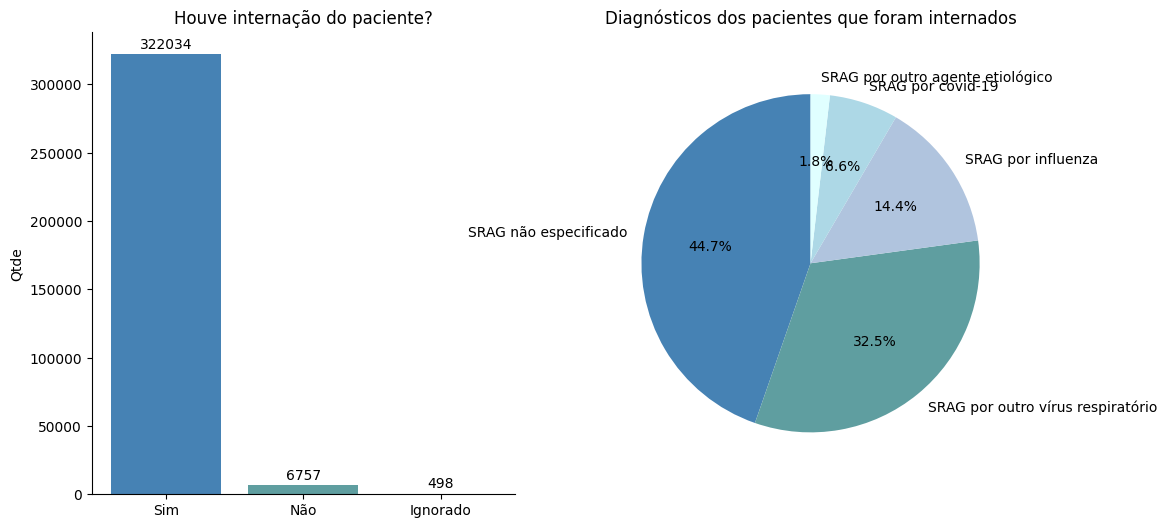

In [12]:
df_SRAG['INTERNACAO'] = df_SRAG['HOSPITAL'].map({
    1: 'Sim',
    2: 'Não', 
    9: 'Ignorado'
}).copy()

df_SRAG['CLASSIFICACAO_SRAG'] = df_SRAG['CLASSI_FIN'].map({
    1: 'SRAG por influenza',
    2: 'SRAG por outro vírus respiratório',
    3: 'SRAG por outro agente etiológico',
    4: 'SRAG não especificado',
    5: 'SRAG por covid-19'
}).copy()

fig, axs = plt.subplots(1,2, figsize=(12,6))

bars = axs[0].bar(df_SRAG.INTERNACAO.value_counts().index, df_SRAG.INTERNACAO.value_counts().values, color=colors)
axs[0].bar_label(bars, padding=2, color = 'black', fontsize = 10)
axs[0].set(title='Houve internação do paciente?', ylabel = 'Qtde')
axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)

#filtrar pacientes que foram para a UTI
df_UTI = df_SRAG.loc[df_SRAG['UTI'] == 1]

diagnosticos = df_UTI['CLASSIFICACAO_SRAG'].value_counts()

#criação do gráfico de pizza
axs[1].pie(diagnosticos, labels=diagnosticos.index, autopct='%1.1f%%', startangle=90, colors=['steelblue', 'cadetblue', 'lightsteelblue', 'lightblue', 'lightcyan'])
axs[1].set_title("Diagnósticos dos pacientes que foram internados", pad=20)

plt.show()


* Como a Síndrome Respiratória Aguda Grave (SRAG) é um quadro clínico de complicação grave, a maioria dos pacientes precisaram ficar internados para o acompanhamento especializado.

* A seguir os pacientes que usaram ou não suporte ventilatório na internação.

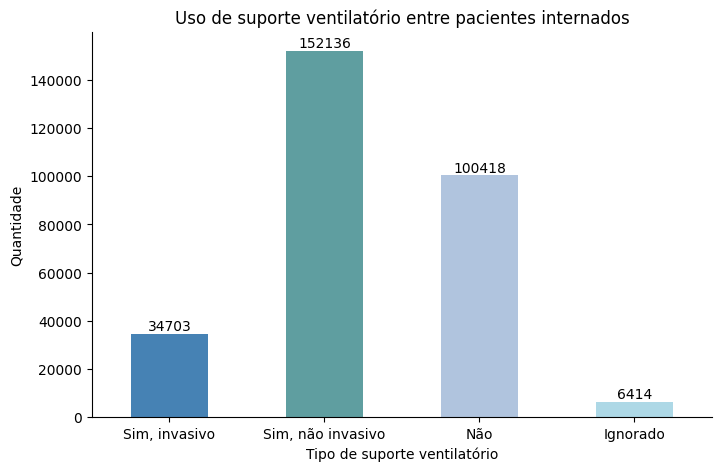

In [15]:
# Filtrar apenas internados
internados = df_SRAG[df_SRAG['HOSPITAL'] == 1].copy()

# Contagem suporte ventilatório
suporte = (
    internados['SUPORT_VEN']
    .value_counts()
    .sort_index()
)

# Renomear categorias
suporte.index = [
    'Sim, invasivo',
    'Sim, não invasivo',
    'Não', 
    'Ignorado'
]

# Gráfico
ax = suporte.plot(
    kind='bar',
    figsize=(8,5),
    color=colors
)

plt.title('Uso de suporte ventilatório entre pacientes internados')
plt.xlabel('Tipo de suporte ventilatório')
plt.ylabel('Quantidade')

# Valores acima das barras
for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=0)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

In [16]:
# Lista de fatores de risco
fatores = [
    'CARDIOPATI',
    'DIABETES',
    'OBESIDADE',
    'ASMA',
    'PNEUMOPATI',
    'HEMATOLOGI',
    'NEUROLOGIC',
    'IMUNODEPRE',
    'RENAL',
    'HEPATICA',
    'PUERPERA',
    'SIND_DOWN'
]

# Contagem
contagem_fatores = (
    df_SRAG[fatores]
    .eq(1)
    .sum()
    .sort_values()
)

# Renomear
contagem_fatores.index = [
    'Doença cardiovascular crônica',
    'Diabetes',
    'Obesidade',
    'Asma',
    'Outra pneumática crônica',
    'Doença hematológica crônica',
    'Doença neurológica crônica',
    'Imunodeficiêcia ou Imunodepressão',
    'Renal',
    'Doença hepática crônica',
    'Puérpera',
    'Síndrome de Down'
]

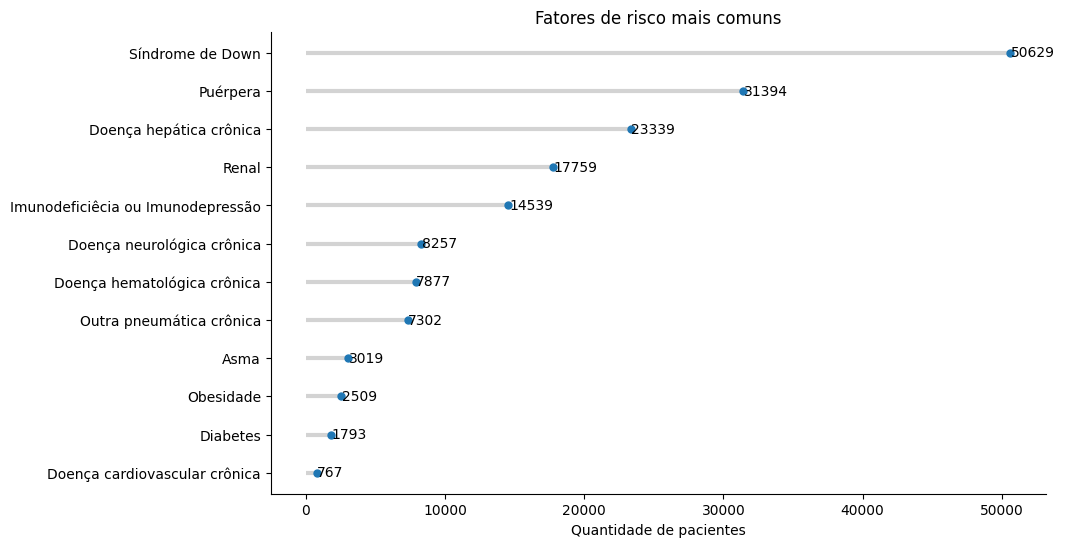

In [24]:
fig, ax = plt.subplots(figsize=(10,6))

# Linhas
ax.hlines(
    y=contagem_fatores.index,
    xmin=0,
    xmax=contagem_fatores.values,
    color='lightgray',
    linewidth=3
)

# Pontos
ax.plot(
    contagem_fatores.values,
    contagem_fatores.index,
    "o",
    markersize=5
)

# Títulos
ax.set_title('Fatores de risco mais comuns')
ax.set_xlabel('Quantidade de pacientes')

# Remover bordas
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Valores ao lado dos pontos
for i, valor in enumerate(contagem_fatores.values):
    ax.text(
        valor + 50,
        i,
        str(valor),
        va='center'
    )

plt.show()

### UTI

In [25]:
def formatar_rotulo(valores):
    def meu_autopct(pct):
        total = sum(valores)
        valor = int(round(pct * total / 100))
        return f'{pct:.1f}%\n({valor})'
    return meu_autopct

C:\Users\Bruna Elen\AppData\Local\Temp\ipykernel_18144\2793936187.py:111: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sns.barplot(
C:\Users\Bruna Elen\AppData\Local\Temp\ipykernel_18144\2793936187.py:129: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sns.barplot(


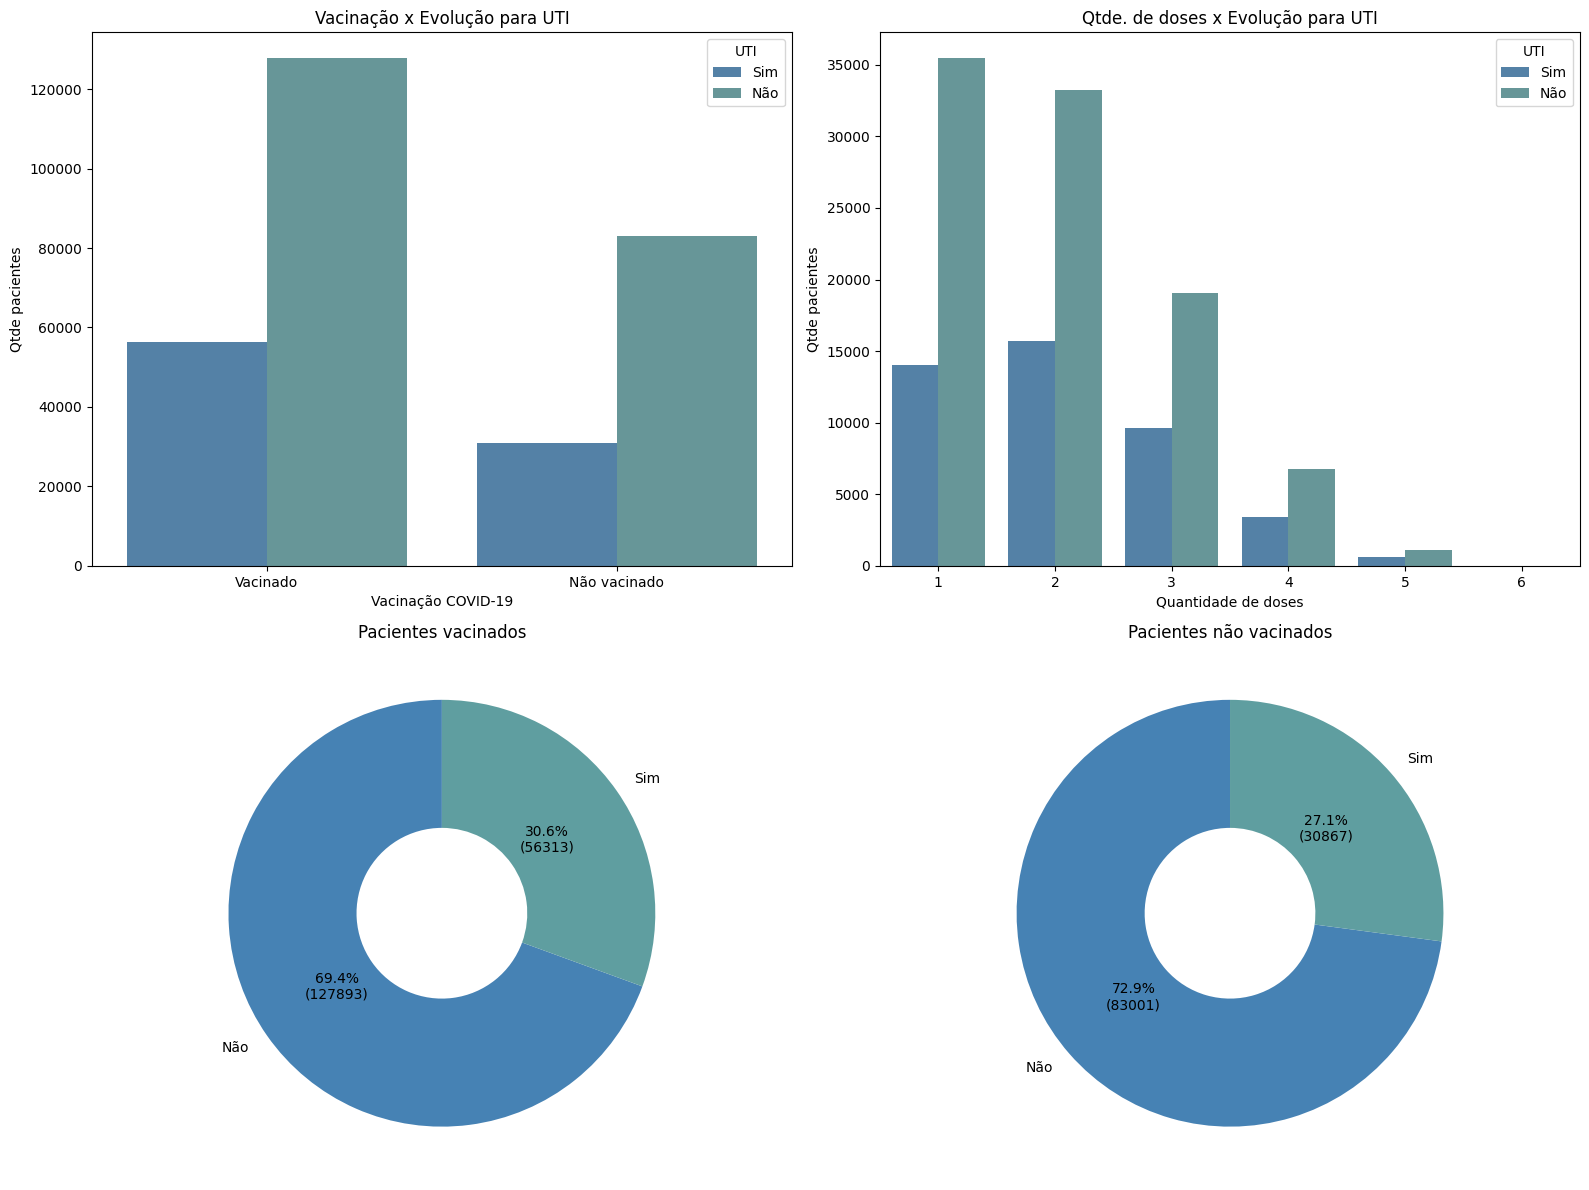

In [26]:
# dicionário para ambos os gráficos
dict = {
    '1': 'Sim', 
    '2': 'Não',
    '9': 'Ignorado'
}

# GRÁFICO 1 — Vacinação x UTI


df_VACINA = df_SRAG.copy()

# converter valores
df_VACINA['UTI'] = (
    df_VACINA['UTI']
    .astype('string')
    .replace(dict)
)

df_VACINA['VACINA_COV'] = (
    df_VACINA['VACINA_COV']
    .astype('string')
    .replace(dict)
)

# renomear categorias
df_VACINA['VACINA_COV'] = (
    df_VACINA['VACINA_COV']
    .replace({
        'Sim': 'Vacinado',
        'Não': 'Não vacinado'
    })
)

# remover ignorados
df_VACINA = df_VACINA[
    (df_VACINA['UTI'] != 'Ignorado') &
    (df_VACINA['VACINA_COV'] != 'Ignorado')
]

vacina_uti = (
    df_VACINA
    .groupby(['VACINA_COV', 'UTI'])
    .size()
    .reset_index(name='Qtde')
)


# GRÁFICO 2 — Doses x UTI


df_DOSES = df_SRAG.loc[df_SRAG['VACINA_COV'] == 1].copy()

# converter valores
df_DOSES['UTI'] = (
    df_DOSES['UTI']
    .astype('string')
    .replace(dict)
)

# remover ignorados
df_DOSES = df_DOSES[
    df_DOSES['UTI'] != 'Ignorado'
]

# calcular número de doses
df_DOSES['NUMERO_DOSES'] = (
    df_DOSES[
        ['DOSE_1_COV', 'DOSE_2_COV',
         'DOSE_REF', 'DOSE_2REF',
         'DOSE_ADIC', 'DOS_RE_BI']
    ]
    .notna()
    .sum(axis=1)
)

# remover quem não tomou nenhuma dose
df_DOSES = df_DOSES[
    df_DOSES['NUMERO_DOSES'] > 0
]

# agrupamento
doses_uti = (
    df_DOSES
    .groupby(['NUMERO_DOSES', 'UTI'])
    .size()
    .reset_index(name='Qtde')
)

# Separar grupos
vacinados = df_VACINA[
    df_VACINA['VACINA_COV'] == 'Vacinado'
]

nao_vacinados = df_VACINA[
    df_VACINA['VACINA_COV'] == 'Não vacinado'
]

# Contagem de UTI em cada grupo
vacinados_uti = vacinados['UTI'].value_counts()

nao_vacinados_uti = nao_vacinados['UTI'].value_counts()



fig, axs = plt.subplots(2, 2, figsize=(16, 12))


# BARRAS 1

sns.barplot(
    data=vacina_uti,
    x='VACINA_COV',
    y='Qtde',
    hue='UTI',
    order=['Vacinado', 'Não vacinado'],
    hue_order=['Sim', 'Não'],
    ax=axs[0,0],
    palette=colors
)

axs[0,0].set_title('Vacinação x Evolução para UTI')
axs[0,0].set_xlabel('Vacinação COVID-19')
axs[0,0].set_ylabel('Qtde pacientes')


# BARRAS 2

sns.barplot(
    data=doses_uti,
    x='NUMERO_DOSES',
    y='Qtde',
    hue='UTI',
    hue_order=['Sim', 'Não'],
    ax=axs[0,1],
    palette=colors
)

axs[0,1].set_title('Qtde. de doses x Evolução para UTI')
axs[0,1].set_xlabel('Quantidade de doses')
axs[0,1].set_ylabel('Qtde pacientes')


# ROSCA 1 — VACINADOS


axs[1,0].pie(
    vacinados_uti.values,
    labels=vacinados_uti.index,
    autopct=formatar_rotulo(vacinados_uti.values),
    startangle=90,
    colors=colors,
    wedgeprops={'width': 0.6}
)

axs[1,0].set_title('Pacientes vacinados')


# ROSCA 2 — NÃO VACINADOS


axs[1,1].pie(
    nao_vacinados_uti.values,
    labels=nao_vacinados_uti.index,
    autopct=formatar_rotulo(nao_vacinados_uti.values),
    startangle=90,
    colors=colors,
    wedgeprops={'width': 0.6}
)

axs[1,1].set_title('Pacientes não vacinados')

# =========================

plt.tight_layout()

plt.show()

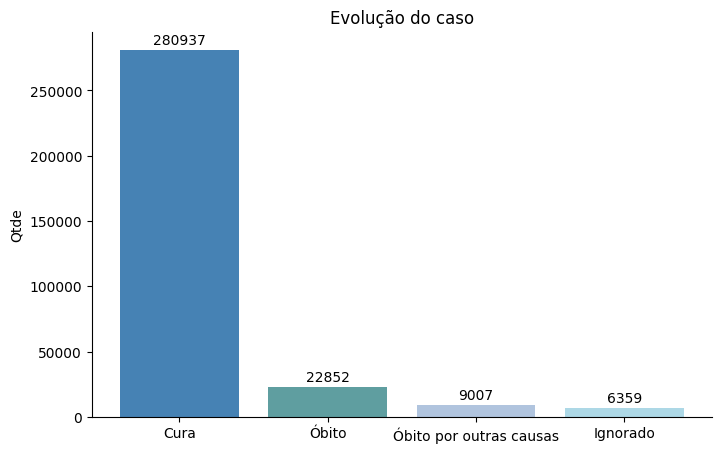

In [27]:
df_SRAG['RESULTADO'] = df_SRAG['EVOLUCAO'].map(
    {
        1: 'Cura',
        2: 'Óbito',
        3: 'Óbito por outras causas', 
        9: 'Ignorado'
    }
).copy()

fig, axs = plt.subplots(figsize=(8,5))

bars = axs.bar(df_SRAG.RESULTADO.value_counts().index, df_SRAG.RESULTADO.value_counts().values, color=colors)
axs.bar_label(bars, padding=2, color = 'black', fontsize = 10)
axs.set(title = 'Evolução do caso', ylabel = 'Qtde')
axs.spines['top'].set_visible(False)
axs.spines['right'].set_visible(False)

plt.show()